# Speech Deepfake Detection — 4 Methods Comparison

Chạy 4 phương pháp trên ASVspoof2019 LA, so sánh kết quả:

| # | Model | Type | Params |
|---|-------|------|--------|
| 1 | LFCC + LCNN | Traditional DL | ~60K |
| 2 | AASIST | End-to-end GAT | ~297K |
| 3 | AASIST-L | End-to-end GAT (light) | ~85K |
| 4 | AASIST3 | SSL (Wav2Vec2) + KAN + GAT | ~100M+ |

**Dataset:** [ASVspoof 2019](https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset)

---

## Part 0: Setup chung

In [1]:
# ═══════════════════════════════════════════
# 0.1  Kiểm tra GPU
# ═══════════════════════════════════════════
!nvidia-smi
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


/bin/bash: line 1: nvidia-smi: command not found
PyTorch: 2.10.0+cpu
CUDA: False


In [2]:
# ═══════════════════════════════════════════
# 0.2  Dataset paths (hardcoded cho Kaggle)
# ═══════════════════════════════════════════
import os

BASE = '/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA'
RESULTS_DIR = '/kaggle/working/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_FLAC_DIR = f'{BASE}/ASVspoof2019_LA_train/flac'
EVAL_FLAC_DIR  = f'{BASE}/ASVspoof2019_LA_eval/flac'
TRAIN_PROTOCOL = f'{BASE}/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'
EVAL_PROTOCOL  = f'{BASE}/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt'

# Verify
for name, path in [('Train FLAC', TRAIN_FLAC_DIR), ('Eval FLAC', EVAL_FLAC_DIR),
                    ('Train Proto', TRAIN_PROTOCOL), ('Eval Proto', EVAL_PROTOCOL)]:
    ok = '' if os.path.exists(path) else ''
    print(f'  {ok} {name:12s}: {path}')

# Đếm nhanh
n_eval = len(os.listdir(EVAL_FLAC_DIR))
n_train = len(os.listdir(TRAIN_FLAC_DIR))
print(f'\n  Train files: {n_train:,}')
print(f'  Eval files : {n_eval:,}')

   Train FLAC  : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_train/flac
   Eval FLAC   : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_eval/flac
   Train Proto : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
   Eval Proto  : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt

  Train files: 25,380
  Eval files : 71,933


In [3]:
# ═══════════════════════════════════════════
# 0.3  Utility functions dùng chung
# ═══════════════════════════════════════════
import numpy as np
import torchaudio
from sklearn.metrics import roc_curve, det_curve
from tqdm import tqdm
import time

def compute_eer(scores, labels):
    """Compute Equal Error Rate."""
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2 * 100

def load_protocol(protocol_file):
    """Load protocol file, trả về list of (utt_id, label)."""
    items = []
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            utt_id = parts[1]
            label = 1 if parts[4] == 'bonafide' else 0
            items.append((utt_id, label))
    return items

# Dict lưu kết quả tất cả models
ALL_RESULTS = {}

print(' Utilities ready!')

 Utilities ready!


In [4]:
import os

BASE = '/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA'

if os.path.exists(BASE):
    for item in sorted(os.listdir(BASE)):
        print(f'  {item}')
else:
    # Thử path khác
    ALT = '/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA'
    print(f'LA/LA không tồn tại. Thử LA/:')
    for item in sorted(os.listdir(ALT)):
        print(f'  {item}')

  ASVspoof2019_LA_asv_protocols
  ASVspoof2019_LA_asv_scores
  ASVspoof2019_LA_cm_protocols
  ASVspoof2019_LA_dev
  ASVspoof2019_LA_eval
  ASVspoof2019_LA_train
  README.LA.txt


In [5]:
!find /kaggle/input -name '*.pkl'


/kaggle/input/datasets/minhbhm/asvspoof21-results/all_results_asvspoof_21.pkl
/kaggle/input/datasets/minhbhm/asvspoof19-results/all_results_asvspooft_19.pkl


In [6]:
# import pickle, glob, os

# possible_paths = [
#     '/kaggle/working/results/all_results_asvspooft_19.pkl',
#     '/kaggle/working/all_results_asvspooft_19.pkl',
#     *glob.glob('/kaggle/input/datasets/minhbhm/asvspoof19-results/all_results_asvspooft_19.pkl', recursive=True),
# ]

# LOADED = False
# for path in possible_paths:
#     if os.path.exists(path):
#         with open(path, 'rb') as f:
#             ALL_RESULTS = pickle.load(f)
#         LOADED = True
#         print(f' Loaded từ: {path}')
#         for name, data in sorted(ALL_RESULTS.items(), key=lambda x: x[1]['eer']):
#             print(f"   {name:15s}  EER = {data['eer']:.2f}%")
#         print('\n Chạy thẳng Part 4.')
#         break

# if not LOADED:
#     print(' Chưa có kết quả. Chạy Part 1→2→3 trước.')

In [7]:
# # ═══════════════════════════════════════════
# # 0.4  Copy dataset sang local SSD (tăng tốc I/O 3-5x)
# # ═══════════════════════════════════════════
# import shutil, time

# LOCAL_BASE = '/kaggle/working/LA_local'
# LOCAL_EVAL = f'{LOCAL_BASE}/ASVspoof2019_LA_eval/flac'
# LOCAL_TRAIN = f'{LOCAL_BASE}/ASVspoof2019_LA_train/flac'

# if os.path.exists(LOCAL_EVAL):
#     print(' Dataset đã có trên local SSD.')
# else:
#     print(' Copying dataset sang local SSD (nhanh hơn 3-5x cho inference)...')
#     t0 = time.time()
#     shutil.copytree(EVAL_FLAC_DIR, LOCAL_EVAL)
#     print(f'   Eval copied ({time.time()-t0:.0f}s)')
#     t1 = time.time()
#     shutil.copytree(TRAIN_FLAC_DIR, LOCAL_TRAIN)
#     print(f'   Train copied ({time.time()-t1:.0f}s)')
#     print(f' Done! Total: {time.time()-t0:.0f}s')

# # Ghi đè paths → tất cả cells sau dùng local
# EVAL_FLAC_DIR = LOCAL_EVAL
# TRAIN_FLAC_DIR = LOCAL_TRAIN
# print(f'\n Eval : {EVAL_FLAC_DIR}')
# print(f' Train: {TRAIN_FLAC_DIR}')

---
## Part 1: AASIST & AASIST-L

**Paper:** Jung et al., ICASSP 2022 | **Params:** AASIST ~297K, AASIST-L ~85K

End-to-end model dùng Graph Attention Network trên spectro-temporal domain. Pretrained weights có sẵn.

In [8]:
# ═══════════════════════════════════════════
# 1.1  Clone & Setup AASIST
# ═══════════════════════════════════════════
%cd /kaggle/working
!rm -rf aasist
!git clone https://github.com/clovaai/aasist.git
!pip install -q soundfile

print('\n Pretrained weights:')
!ls -lh /kaggle/working/aasist/models/weights/
print(' AASIST repo ready!')

/kaggle/working
Cloning into 'aasist'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 38 (delta 12), reused 6 (delta 6), pack-reused 10 (from 1)
Receiving objects: 100% (38/38), 1.43 MiB | 22.47 MiB/s, done.
Resolving deltas: 100% (12/12), done.

 Pretrained weights:
total 1.7M
-rw-r--r-- 1 root root 417K Apr  9 02:10 AASIST-L.pth
-rw-r--r-- 1 root root 1.3M Apr  9 02:10 AASIST.pth
 AASIST repo ready!


In [9]:
# ═══════════════════════════════════════════
# 1.2  Load cả 2 models
# ═══════════════════════════════════════════
import sys, json, importlib
sys.path.insert(0, '/kaggle/working/aasist')
%cd /kaggle/working/aasist

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# AASIST
with open('config/AASIST.conf') as f:
    cfg = json.load(f)
mod = importlib.import_module(f'models.{cfg["model_config"]["architecture"]}')
aasist_model = mod.Model(cfg['model_config']).to(device)
aasist_model.load_state_dict(torch.load('models/weights/AASIST.pth', map_location=device))
aasist_model.eval()

# AASIST-L
with open('config/AASIST-L.conf') as f:
    cfg_l = json.load(f)
mod_l = importlib.import_module(f'models.{cfg_l["model_config"]["architecture"]}')
aasist_l_model = mod_l.Model(cfg_l['model_config']).to(device)
aasist_l_model.load_state_dict(torch.load('models/weights/AASIST-L.pth', map_location=device))
aasist_l_model.eval()

print(f' AASIST   loaded — {sum(p.numel() for p in aasist_model.parameters()):>10,} params')
print(f' AASIST-L loaded — {sum(p.numel() for p in aasist_l_model.parameters()):>10,} params')

/kaggle/working/aasist
 AASIST   loaded —    297,866 params
 AASIST-L loaded —     85,306 params


In [10]:
# # ═══════════════════════════════════════════
# # 1.3  Inference function cho AASIST
# # ═══════════════════════════════════════════
# def predict_aasist(model, audio_path, device='cuda', cut=64600):
#     wav, sr = torchaudio.load(audio_path)
#     if sr != 16000:
#         wav = torchaudio.transforms.Resample(sr, 16000)(wav)
#     if wav.shape[0] > 1:
#         wav = wav.mean(dim=0, keepdim=True)
#     if wav.shape[1] < cut:
#         wav = torch.nn.functional.pad(wav, (0, cut - wav.shape[1]))
#     else:
#         wav = wav[:, :cut]
#     wav = wav.to(device)
#     with torch.no_grad():
#         _, out = model(wav)
#     scores = out.softmax(dim=1).cpu().numpy()[0]
#     return float(scores[1])  # bonafide score

# print(' predict_aasist() ready!')

In [11]:
# # ═══════════════════════════════════════════
# # 1.4  Evaluate AASIST & AASIST-L
# # ═══════════════════════════════════════════
# protocol = load_protocol(EVAL_PROTOCOL)
# print(f'Protocol: {len(protocol):,} utterances\n')

# for model_obj, name in [(aasist_model, 'AASIST'), (aasist_l_model, 'AASIST-L')]:
#     scores, labels = [], []
#     t0 = time.time()
#     for utt_id, label in tqdm(protocol, desc=name):
#         path = os.path.join(EVAL_FLAC_DIR, f'{utt_id}.flac')
#         if os.path.exists(path):
#             try:
#                 s = predict_aasist(model_obj, path, device)
#                 scores.append(s)
#                 labels.append(label)
#             except:
#                 pass
#     elapsed = time.time() - t0
#     eer = compute_eer(np.array(scores), np.array(labels))
#     ALL_RESULTS[name] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
#     print(f' {name:10s} EER = {eer:.2f}%  ({elapsed:.0f}s)\n')

# # Free GPU memory
# del aasist_model, aasist_l_model
# torch.cuda.empty_cache()
# print(' GPU memory freed.')

---
## Part 2: AASIST3 — Wav2Vec2 + KAN + AASIST

**Paper:** Borodin et al., ASVspoof Workshop 2024 | **HuggingFace:** MTUCI/AASIST3

SSL front-end (Wav2Vec2) + Kolmogorov-Arnold Networks + AASIST back-end. Load từ HuggingFace.

In [12]:
# # ═══════════════════════════════════════════
# # 2.1  Clone & Setup AASIST3
# # ═══════════════════════════════════════════
# %cd /kaggle/working
# !rm -rf AASIST3
# !git clone https://github.com/mtuciru/AASIST3.git
# !pip install -q transformers huggingface_hub
# print(' AASIST3 repo ready!')

In [13]:
# # ═══════════════════════════════════════════
# # 2.2  Load model từ HuggingFace
# # ═══════════════════════════════════════════
# import sys
# sys.path.insert(0, '/kaggle/working/AASIST3')
# %cd /kaggle/working/AASIST3

# from model import aasist3

# print(' Downloading AASIST3 from HuggingFace...')
# aasist3_model = aasist3.from_pretrained('MTUCI/AASIST3')
# aasist3_model.eval()
# aasist3_model = aasist3_model.to(device)

# print(f' AASIST3 loaded — {sum(p.numel() for p in aasist3_model.parameters()):>10,} params')

In [14]:
# # ═══════════════════════════════════════════
# # 2.3  Inference function cho AASIST3
# # ═══════════════════════════════════════════
# def predict_aasist3(model, audio_path, device='cuda', cut=64600):
#     wav, sr = torchaudio.load(audio_path)
#     if sr != 16000:
#         wav = torchaudio.transforms.Resample(sr, 16000)(wav)
#     if wav.shape[0] > 1:
#         wav = wav.mean(dim=0, keepdim=True)
#     if wav.shape[1] < cut:
#         wav = torch.nn.functional.pad(wav, (0, cut - wav.shape[1]))
#     else:
#         wav = wav[:, :cut]
#     wav = wav.to(device)
#     with torch.no_grad():
#         out = model(wav)
#     probs = torch.softmax(out, dim=1).cpu().numpy()[0]
#     return float(probs[0])  # bonafide score (index 0 cho AASIST3)

# print(' predict_aasist3() ready!')

In [15]:
# # ═══════════════════════════════════════════
# # DEBUG: Kiểm tra AASIST3 score direction
# # ═══════════════════════════════════════════
# import os, torch, torchaudio
# import numpy as np

# protocol = load_protocol(EVAL_PROTOCOL)
# print(f'Protocol: {len(protocol):,} utterances\n')

# # Lấy 20 bonafide + 20 spoof
# samples_b, samples_s = [], []
# for utt_id, label in protocol:
#     path = os.path.join(EVAL_FLAC_DIR, f'{utt_id}.flac')
#     if label == 1 and len(samples_b) < 20:
#         samples_b.append((utt_id, path))
#     elif label == 0 and len(samples_s) < 20:
#         samples_s.append((utt_id, path))
#     if len(samples_b) >= 20 and len(samples_s) >= 20:
#         break

# # Reload AASIST3
# import sys
# sys.path.insert(0, '/kaggle/working/AASIST3')
# os.chdir('/kaggle/working/AASIST3')
# from model import aasist3
# aasist3_model = aasist3.from_pretrained('MTUCI/AASIST3').eval().to(device)

# def get_raw_output(model, path, device='cuda', cut=64600):
#     wav, sr = torchaudio.load(path)
#     if sr != 16000:
#         wav = torchaudio.transforms.Resample(sr, 16000)(wav)
#     if wav.shape[0] > 1:
#         wav = wav.mean(dim=0, keepdim=True)
#     if wav.shape[1] < cut:
#         wav = torch.nn.functional.pad(wav, (0, cut - wav.shape[1]))
#     else:
#         wav = wav[:, :cut]
#     with torch.no_grad():
#         out = model(wav.to(device))
#     probs = torch.softmax(out, dim=1).cpu().numpy()[0]
#     return probs  # [prob_class0, prob_class1]

# print('=== BONAFIDE samples ===')
# for utt_id, path in samples_b[:5]:
#     p = get_raw_output(aasist3_model, path, device)
#     print(f'  {utt_id}: class0={p[0]:.4f}  class1={p[1]:.4f}  argmax={np.argmax(p)}')

# print('\n=== SPOOF samples ===')
# for utt_id, path in samples_s[:5]:
#     p = get_raw_output(aasist3_model, path, device)
#     print(f'  {utt_id}: class0={p[0]:.4f}  class1={p[1]:.4f}  argmax={np.argmax(p)}')

# # Test cả 2 hướng score
# scores_dir0, scores_dir1, labels_test = [], [], []
# for utt_id, path in samples_b + samples_s:
#     label = 1 if (utt_id, path) in samples_b else 0
#     p = get_raw_output(aasist3_model, path, device)
#     scores_dir0.append(p[0])  # class0 = bonafide?
#     scores_dir1.append(p[1])  # class1 = bonafide?
#     labels_test.append(label)

# from sklearn.metrics import roc_curve
# def quick_eer(scores, labels):
#     fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
#     fnr = 1 - tpr
#     idx = np.nanargmin(np.abs(fpr - fnr))
#     return (fpr[idx] + fnr[idx]) / 2 * 100

# eer0 = quick_eer(np.array(scores_dir0), np.array(labels_test))
# eer1 = quick_eer(np.array(scores_dir1), np.array(labels_test))

In [16]:
# # ═══════════════════════════════════════════
# # 2.4  Evaluate AASIST3
# # ═══════════════════════════════════════════
# scores, labels = [], []
# t0 = time.time()

# for utt_id, label in tqdm(protocol, desc='AASIST3'):
#     path = os.path.join(EVAL_FLAC_DIR, f'{utt_id}.flac')
#     if os.path.exists(path):
#         try:
#             s = predict_aasist3(aasist3_model, path, device)
#             scores.append(s)
#             labels.append(label)
#         except:
#             pass

# elapsed = time.time() - t0
# eer = compute_eer(np.array(scores), np.array(labels))
# ALL_RESULTS['AASIST3'] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
# print(f'\n AASIST3 EER = {eer:.2f}%  ({elapsed:.0f}s)')

# del aasist3_model
# torch.cuda.empty_cache()
# print(' GPU memory freed.')

---
## Part 3: LFCC + LCNN — Traditional DL Baseline

Hand-crafted features (LFCC) + Light CNN. Cần **train từ đầu** (~10–15 phút).

Giá trị: cho thấy sự chênh lệch rõ ràng so với AASIST và SSL-based methods.

In [17]:
# ═══════════════════════════════════════════
# 3.1  Define LFCC extractor + LCNN model
# ═══════════════════════════════════════════
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class SimpleLCNN(nn.Module):
    """Light CNN for anti-spoofing."""
    def __init__(self, n_lfcc=60):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

lfcc_transform = torchaudio.transforms.LFCC(
    sample_rate=16000, n_lfcc=60,
    speckwargs={'n_fft': 512, 'hop_length': 160, 'win_length': 320}
)

class ASVspoofLFCC(Dataset):
    def __init__(self, flac_dir, protocol_file, max_frames=400):
        self.flac_dir = flac_dir
        self.max_frames = max_frames
        self.items = load_protocol(protocol_file)

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        utt_id, label = self.items[idx]
        wav, sr = torchaudio.load(os.path.join(self.flac_dir, f'{utt_id}.flac'))
        if sr != 16000:
            wav = torchaudio.transforms.Resample(sr, 16000)(wav)
        feat = lfcc_transform(wav)  # [1, 60, T]
        T = feat.shape[2]
        if T < self.max_frames:
            feat = torch.nn.functional.pad(feat, (0, self.max_frames - T))
        else:
            feat = feat[:, :, :self.max_frames]
        return feat, label

lcnn = SimpleLCNN().to(device)
print(f' LCNN model — {sum(p.numel() for p in lcnn.parameters()):,} params')

 LCNN model — 101,506 params


In [18]:
# # ═══════════════════════════════════════════
# # 3.2  Train LFCC + LCNN
# # ═══════════════════════════════════════════
# # Kaggle input is read-only → dùng trực tiếp

# print('🏋️ Training LFCC+LCNN...')
# train_ds = ASVspoofLFCC(TRAIN_FLAC_DIR, TRAIN_PROTOCOL)
# train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)

# optimizer = torch.optim.Adam(lcnn.parameters(), lr=1e-3, weight_decay=1e-4)
# criterion = nn.CrossEntropyLoss()
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# for epoch in range(10):
#     lcnn.train()
#     total_loss, correct, total = 0, 0, 0
#     for feat, label in tqdm(train_dl, desc=f'Epoch {epoch+1}/10', leave=False):
#         feat, label = feat.to(device), label.to(device)
#         logits = lcnn(feat)
#         loss = criterion(logits, label)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item() * label.size(0)
#         correct += (logits.argmax(1) == label).sum().item()
#         total += label.size(0)
#     scheduler.step()
#     print(f'  Epoch {epoch+1:2d}/10 — Loss: {total_loss/total:.4f}, Acc: {correct/total*100:.1f}%')

# torch.save(lcnn.state_dict(), '/kaggle/working/lfcc_lcnn.pth')
# print('\n Training done!')

In [19]:
# # ═══════════════════════════════════════════
# # 3.3  Evaluate LFCC + LCNN
# # ═══════════════════════════════════════════
# protocol = load_protocol(EVAL_PROTOCOL)
# print(f'Protocol: {len(protocol):,} utterances\n')

# lcnn.eval()
# scores, labels = [], []
# errors = 0
# t0 = time.time()

# for i, (utt_id, label) in enumerate(tqdm(protocol, desc='LFCC+LCNN')):
#     path = os.path.join(EVAL_FLAC_DIR, f'{utt_id}.flac')
#     if os.path.exists(path):
#         try:
#             wav, sr = torchaudio.load(path)
#             if sr != 16000:
#                 wav = torchaudio.transforms.Resample(sr, 16000)(wav)
#             feat = lfcc_transform(wav)
#             T = feat.shape[2]
#             if T < 400:
#                 feat = torch.nn.functional.pad(feat, (0, 400 - T))
#             else:
#                 feat = feat[:, :, :400]
#             with torch.no_grad():
#                 logits = lcnn(feat.unsqueeze(0).to(device))
#                 s = torch.softmax(logits, dim=1)[0, 1].item()
#             scores.append(s)
#             labels.append(label)
#         except Exception as e:
#             errors += 1
#             # In lỗi cho 5 file đầu tiên để debug
#             if errors <= 5:
#                 print(f' Error on {utt_id}: {type(e).__name__}: {e}')

# elapsed = time.time() - t0
# print(f'\nProcessed: {len(scores):,} | Errors: {errors:,} | Skipped (not found): {len(protocol)-len(scores)-errors:,}')

# if len(scores) > 0:
#     eer = compute_eer(np.array(scores), np.array(labels))
#     ALL_RESULTS['LFCC+LCNN'] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
#     print(f' LFCC+LCNN EER = {eer:.2f}%  ({elapsed:.0f}s)')
# else:
#     print(' Không có scores nào. Xem lỗi ở trên để debug.')

# del lcnn
# torch.cuda.empty_cache()

In [20]:
# # ═══════════════════════════════════════════
# # SAVE: Lưu tất cả kết quả để dùng lại
# # ═══════════════════════════════════════════
# import pickle, json

# SAVE_PATH = '/kaggle/working/all_results.pkl'
# SAVE_JSON = '/kaggle/working/all_results_summary.json'

# # Lưu toàn bộ (scores + labels + eer) — dùng pickle vì chứa numpy arrays
# with open(SAVE_PATH, 'wb') as f:
#     pickle.dump(ALL_RESULTS, f)

# # Lưu summary dạng JSON (dễ đọc)
# summary = {}
# for name, data in ALL_RESULTS.items():
#     summary[name] = {
#         'eer': round(data['eer'], 4),
#         'n_scores': len(data['scores']),
#         'n_bonafide': int((data['labels'] == 1).sum()),
#         'n_spoof': int((data['labels'] == 0).sum()),
#     }

# with open(SAVE_JSON, 'w') as f:
#     json.dump(summary, f, indent=2)

# print('Đã lưu kết quả:')
# print(f'   {SAVE_PATH} ({os.path.getsize(SAVE_PATH)/1e6:.1f} MB)')
# print(f'   {SAVE_JSON}')
# print()
# print('Summary:')
# for name, info in sorted(summary.items(), key=lambda x: x[1]['eer']):
#     print(f"   {name:15s}  EER = {info['eer']:.2f}%  ({info['n_scores']:,} utterances)")
# print()
# print('='*60)
# print('ĐỂ DÙNG LẠI LẦN SAU:')
# print('   1. Bấm "Save Version" (nút trên cùng bên phải)')
# print('   2. Chọn "Save & Run All" hoặc "Quick Save"')
# print('   3. Sau khi save xong, vào tab Output')
# print('   4. Bấm "New Dataset" → đặt tên ví dụ "asvspoof-results"')
# print('   5. Lần sau: Add Data → chọn dataset đó')
# print('   6. Load bằng cell LOAD bên dưới')
# print('='*60)

---
## Part 4: Tổng hợp & So sánh kết quả

In [21]:
# # ═══════════════════════════════════════════
# # 4.1  Bảng so sánh
# # ═══════════════════════════════════════════
# print('\n' + '=' * 60)
# print('       EVALUATION RESULTS — ASVspoof2019 LA')
# print('=' * 60)
# print(f'{"Model":15s} | {"Type":25s} | {"EER (%)":>10s}')
# print('-' * 60)

# # Sắp xếp theo EER
# for name, data in sorted(ALL_RESULTS.items(), key=lambda x: x[1]['eer']):
#     types = {
#         'AASIST': 'End-to-end GAT (297K)',
#         'AASIST-L': 'End-to-end GAT (85K)',
#         'AASIST3': 'SSL+KAN+GAT (~100M)',
#         'LFCC+LCNN': 'Traditional DL (~60K)',
#     }
#     t = types.get(name, '')
#     print(f'{name:15s} | {t:25s} | {data["eer"]:>9.2f}%')

# print('=' * 60)

In [22]:
/

()

In [23]:
# # ═══════════════════════════════════════════
# # 4.3  Score distributions
# # ═══════════════════════════════════════════
# n_models = len(ALL_RESULTS)
# fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
# if n_models == 1:
#     axes = [axes]

# for ax, (name, data) in zip(axes, sorted(ALL_RESULTS.items(), key=lambda x: x[1]['eer'])):
#     bonafide = data['scores'][data['labels'] == 1]
#     spoof = data['scores'][data['labels'] == 0]
#     ax.hist(bonafide, bins=80, alpha=0.7, label='Bonafide', color='#2ecc71', density=True)
#     ax.hist(spoof, bins=80, alpha=0.7, label='Spoof', color='#e74c3c', density=True)
#     ax.set_title(f"{name}\nEER = {data['eer']:.2f}%", fontweight='bold')
#     ax.set_xlabel('Bonafide Score')
#     ax.legend(fontsize=9)

# plt.suptitle('Score Distributions', fontsize=14, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.savefig(f'{RESULTS_DIR}/score_distributions.png', dpi=150, bbox_inches='tight')
# plt.show()

In [24]:
# # ═══════════════════════════════════════════
# # 4.4  Lưu tất cả kết quả
# # ═══════════════════════════════════════════
# import json as jsonlib

# # Save scores
# for name, data in ALL_RESULTS.items():
#     safe_name = name.replace('+', '_').replace(' ', '_')
#     np.savez(f'{RESULTS_DIR}/scores_{safe_name}.npz',
#              scores=data['scores'], labels=data['labels'], eer=data['eer'])

# # Save summary
# summary = {name: {'eer': float(data['eer'])} for name, data in ALL_RESULTS.items()}
# with open(f'{RESULTS_DIR}/summary.json', 'w') as f:
#     jsonlib.dump(summary, f, indent=2)

# print(' Tất cả kết quả đã lưu tại /kaggle/working/results/')
# !ls -lh {RESULTS_DIR}/

---
##  Kết luận

| Thế hệ | Model | Đặc trưng | EER range |
|---------|-------|-----------|----------|
| Traditional | LFCC+LCNN | Hand-crafted features + simple CNN | ... |
| End-to-end | AASIST / AASIST-L | Raw waveform → Graph Attention | ... |
| SSL-enhanced | AASIST3 | Wav2Vec2 pretrained + KAN + GAT | ... |

**Key insights:**

## Part 5: ASVSpoof 2021 Evaluation & Comparison to ASVSpoof 2019

In [25]:
# ═══════════════════════════════════════════
# 5.0  Paths cho ASVspoof2021 (Kaggle dataset có sẵn)
# ═══════════════════════════════════════════
import os

ASV21_BASE = '/kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021'

# ── DF eval: gộp 3 parts vào 1 folder bằng symlinks ──
DF_FLAC_DIR = '/kaggle/working/asvspoof2021_DF_flac'
os.makedirs(DF_FLAC_DIR, exist_ok=True)

if len(os.listdir(DF_FLAC_DIR)) < 100:
    print('🔗 Tạo symlinks gộp DF eval parts...')
    count = 0
    for part in ['ASVspoof2021_DF_eval_part00', 'ASVspoof2021_DF_eval_part01', 'ASVspoof2021_DF_eval_part02']:
        part_dir = os.path.join(ASV21_BASE, part)
        if not os.path.exists(part_dir):
            continue
        # Tìm thư mục flac bên trong
        for dirpath, _, files in os.walk(part_dir):
            for f in files:
                if f.endswith('.flac'):
                    src = os.path.join(dirpath, f)
                    dst = os.path.join(DF_FLAC_DIR, f)
                    if not os.path.exists(dst):
                        os.symlink(src, dst)
                        count += 1
    print(f'    Linked {count:,} files')
else:
    print(f' DF symlinks đã có ({len(os.listdir(DF_FLAC_DIR)):,} files)')

# ── LA eval ──
LA21_EVAL_DIR = None
la_candidate = os.path.join(ASV21_BASE, 'ASVspoof2021_LA_eval')
for dirpath, dirnames, files in os.walk(la_candidate):
    if any(f.endswith('.flac') for f in files):
        LA21_EVAL_DIR = dirpath
        break
    for d in dirnames:
        if 'flac' in d.lower():
            LA21_EVAL_DIR = os.path.join(dirpath, d)
            break

# ── Keys / Trial files ──
DF_TRIAL = None
LA21_TRIAL = None

# Tìm DF trial
df_keys_dir = os.path.join(ASV21_BASE, 'DF-keys-full')
if os.path.exists(df_keys_dir):
    for dirpath, _, files in os.walk(df_keys_dir):
        for f in files:
            if 'trial' in f.lower() and f.endswith('.txt'):
                DF_TRIAL = os.path.join(dirpath, f)
                break

# Tìm LA trial
la_keys_dir = os.path.join(ASV21_BASE, 'LA-keys-full')
if os.path.exists(la_keys_dir):
    for dirpath, _, files in os.walk(la_keys_dir):
        for f in files:
            if 'trial' in f.lower() and f.endswith('.txt'):
                LA21_TRIAL = os.path.join(dirpath, f)
                break

# ── Verify ──
print(f'\n ASVspoof2021 Paths:')
print(f'  {"" if os.path.exists(DF_FLAC_DIR) and len(os.listdir(DF_FLAC_DIR))>0 else ""} DF FLAC   : {DF_FLAC_DIR} ({len(os.listdir(DF_FLAC_DIR)):,} files)')
print(f'  {"" if LA21_EVAL_DIR else ""} LA FLAC   : {LA21_EVAL_DIR}')
print(f'  {"" if DF_TRIAL else ""} DF Trial  : {DF_TRIAL}')
print(f'  {"" if LA21_TRIAL else ""} LA Trial  : {LA21_TRIAL}')

if DF_TRIAL:
    print(f'\n📄 DF Trial preview:')
    with open(DF_TRIAL) as f:
        for i, line in enumerate(f):
            if i < 3: print(f'  {line.strip()}')
            else: break

🔗 Tạo symlinks gộp DF eval parts...
    Linked 458,871 files

 ASVspoof2021 Paths:
   DF FLAC   : /kaggle/working/asvspoof2021_DF_flac (458,871 files)
   LA FLAC   : /kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021/ASVspoof2021_LA_eval/ASVspoof2021_LA_eval/flac
   DF Trial  : /kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021/DF-keys-full/keys/DF/CM/trial_metadata.txt
   LA Trial  : /kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021/LA-keys-full/keys/LA/CM/trial_metadata.txt

📄 DF Trial preview:
  LA_0023 DF_E_2000011 nocodec asvspoof A14 spoof notrim progress traditional_vocoder - - - -
  TEF2 DF_E_2000013 low_m4a vcc2020 Task1-team20 spoof notrim eval neural_vocoder_nonautoregressive Task1 team20 FF E
  TGF1 DF_E_2000024 mp3m4a vcc2020 Task2-team12 spoof notrim eval traditional_vocoder Task2 team12 FF G


In [26]:
# # ═══════════════════════════════════════════
# # 5.2  Parse ASVspoof2021 DF protocol
# # ═══════════════════════════════════════════
# # ASVspoof2021 DF trial format khác ASVspoof2019:
# # Dòng mẫu: LA_0001 LA_E_1234567 - - - - - bonafide
# # Hoặc:     LA_0001 LA_E_1234567 asvspoof A01 ... spoof

# def load_protocol_2021(trial_file):
#     """Parse ASVspoof2021 trial metadata."""
#     items = []
#     with open(trial_file, 'r') as f:
#         for line in f:
#             parts = line.strip().split()
#             if len(parts) < 5:
#                 continue
#             utt_id = parts[1]
#             # Label là field cuối cùng
#             label_str = parts[5]
#             if label_str == 'bonafide':
#                 label = 1
#             elif label_str == 'spoof':
#                 label = 0
#             else:
#                 continue
#             items.append((utt_id, label))
#     return items

# if DF_TRIAL:
#     protocol_2021 = load_protocol_2021(DF_TRIAL)
#     n_bona = sum(1 for _, l in protocol_2021 if l == 1)
#     n_spoof = sum(1 for _, l in protocol_2021 if l == 0)
#     print(f'ASVspoof2021 DF protocol:')
#     print(f'  Total    : {len(protocol_2021):,}')
#     print(f'  Bonafide : {n_bona:,}')
#     print(f'  Spoof    : {n_spoof:,}')

In [27]:
# # ═══════════════════════════════════════════
# # 5.3  Reload models & Evaluate trên ASVspoof2021 DF
# # ═══════════════════════════════════════════
# import sys, json, importlib

# # Reload AASIST (đã bị del ở Part 1)
# sys.path.insert(0, '/kaggle/working/aasist')
# os.chdir('/kaggle/working/aasist')

# with open('config/AASIST.conf') as f:
#     cfg = json.load(f)
# mod = importlib.import_module(f'models.{cfg["model_config"]["architecture"]}')
# aasist_model = mod.Model(cfg['model_config']).to(device)
# aasist_model.load_state_dict(torch.load('models/weights/AASIST.pth', map_location=device))
# aasist_model.eval()
# print(f' AASIST reloaded')

# # Evaluate
# RESULTS_2021 = {}

# scores, labels = [], []
# t0 = time.time()
# errors = 0
# for utt_id, label in tqdm(protocol_2021, desc='AASIST → ASVspoof2021 DF'):
#     path = os.path.join(DF_FLAC_DIR, f'{utt_id}.flac')
#     if os.path.exists(path):
#         try:
#             s = predict_aasist(aasist_model, path, device)
#             scores.append(s)
#             labels.append(label)
#         except Exception as e:
#             errors += 1
#             if errors <= 3:
#                 print(f'  Error: {e}')

# elapsed = time.time() - t0
# print(f'\nProcessed: {len(scores):,} | Errors: {errors}')

# if len(scores) > 0:
#     eer = compute_eer(np.array(scores), np.array(labels))
#     RESULTS_2021['AASIST'] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
#     print(f' AASIST on ASVspoof2021 DF: EER = {eer:.2f}%')
# else:
#     print(' Không có scores. Kiểm tra path.')

# del aasist_model
# torch.cuda.empty_cache()

In [28]:
# # ═══════════════════════════════════════════
# # 5.4  Evaluate LFCC+LCNN trên ASVspoof2021 DF
# # ═══════════════════════════════════════════

# # Reload LFCC+LCNN
# lcnn = SimpleLCNN().to(device)
# lcnn.load_state_dict(torch.load('/kaggle/working/lfcc_lcnn.pth', map_location=device))
# lcnn.eval()
# print(' LFCC+LCNN reloaded')

# scores, labels = [], []
# errors = 0
# t0 = time.time()

# for utt_id, label in tqdm(protocol_2021, desc='LFCC+LCNN → ASVspoof2021 DF'):
#     path = os.path.join(DF_FLAC_DIR, f'{utt_id}.flac')
#     if os.path.exists(path):
#         try:
#             wav, sr = torchaudio.load(path)
#             if sr != 16000:
#                 wav = torchaudio.transforms.Resample(sr, 16000)(wav)
#             feat = lfcc_transform(wav)
#             T = feat.shape[2]
#             if T < 400:
#                 feat = torch.nn.functional.pad(feat, (0, 400 - T))
#             else:
#                 feat = feat[:, :, :400]
#             with torch.no_grad():
#                 logits = lcnn(feat.unsqueeze(0).to(device))
#                 s = torch.softmax(logits, dim=1)[0, 1].item()
#             scores.append(s)
#             labels.append(label)
#         except Exception as e:
#             errors += 1
#             if errors <= 3:
#                 print(f'  Error: {e}')

# elapsed = time.time() - t0
# print(f'\nProcessed: {len(scores):,} | Errors: {errors}')

# if len(scores) > 0:
#     eer = compute_eer(np.array(scores), np.array(labels))
#     RESULTS_2021['LFCC+LCNN'] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
#     print(f' LFCC+LCNN on ASVspoof2021 DF: EER = {eer:.2f}%')

# del lcnn
# torch.cuda.empty_cache()

In [29]:
# # ═══════════════════════════════════════════
# # 5.5  So sánh ASVspoof2019 vs ASVspoof2021
# # ═══════════════════════════════════════════
# import matplotlib.pyplot as plt

# print('\n' + '=' * 65)
# print('    CROSS-DATASET COMPARISON: ASVspoof2019 LA vs ASVspoof2021 DF')
# print('=' * 65)
# print(f'{"Model":15s} | {"2019 LA EER":>12s} | {"2021 DF EER":>12s} | {"Δ":>8s}')
# print('-' * 65)

# models_both = []
# for name in ALL_RESULTS:
#     if name in RESULTS_2021:
#         eer19 = ALL_RESULTS[name]['eer']
#         eer21 = RESULTS_2021[name]['eer']
#         delta = eer21 - eer19
#         print(f'{name:15s} | {eer19:>11.2f}% | {eer21:>11.2f}% | {delta:>+7.2f}%')
#         models_both.append(name)

# print('=' * 65)
# print('\n EER tăng mạnh trên 2021 DF → codec compression phá hủy spoofing artifacts')

# # Bar chart so sánh
# if models_both:
#     fig, ax = plt.subplots(figsize=(10, 5))
#     x = range(len(models_both))
#     width = 0.35

#     eer19 = [ALL_RESULTS[n]['eer'] for n in models_both]
#     eer21 = [RESULTS_2021[n]['eer'] for n in models_both]

#     bars1 = ax.bar([i - width/2 for i in x], eer19, width, label='ASVspoof2019 LA', color='#2ecc71')
#     bars2 = ax.bar([i + width/2 for i in x], eer21, width, label='ASVspoof2021 DF', color='#e74c3c')

#     for bar, val in zip(bars1, eer19):
#         ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
#                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
#     for bar, val in zip(bars2, eer21):
#         ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
#                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

#     ax.set_ylabel('EER (%)', fontsize=12)
#     ax.set_title('ASVspoof2019 LA vs ASVspoof2021 DF\n(codec compression makes detection much harder)',
#                  fontsize=13, fontweight='bold')
#     ax.set_xticks(x)
#     ax.set_xticklabels(models_both, fontsize=11)
#     ax.legend(fontsize=11)
#     ax.grid(axis='y', alpha=0.3)

#     plt.tight_layout()
#     plt.savefig(f'{RESULTS_DIR}/cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
#     plt.show()

# # Save
# for name, data in RESULTS_2021.items():
#     safe = name.replace('+','_')
#     np.savez(f'{RESULTS_DIR}/scores_2021DF_{safe}.npz',
#              scores=data['scores'], labels=data['labels'], eer=data['eer'])
# print(f'\n Saved to {RESULTS_DIR}/')

---
## Part 6: Error Analysis — Grouped EER Breakdowns

Re-parse protocol files with full metadata (attack type, codec, vocoder) and compute per-group EER.  
**No re-inference needed** — reuses scores from `ALL_RESULTS` and `RESULTS_2021`.

In [30]:
# ═══════════════════════════════════════════
# 6.0  Load saved results (skip re-inference)
# ═══════════════════════════════════════════
import pickle, glob, os
import numpy as np

# --- ASVspoof 2019 LA (single .pkl) ---
paths_2019 = [
    '/kaggle/working/results/all_results_asvspooft_19.pkl',
    '/kaggle/working/all_results_asvspooft_19.pkl',
    *glob.glob('/kaggle/input/datasets/minhbhm/asvspoof19-results/all_results_asvspooft_19.pkl'),
]
for path in paths_2019:
    if os.path.exists(path):
        with open(path, 'rb') as f:
            ALL_RESULTS = pickle.load(f)
        print(f'✅ ALL_RESULTS loaded from: {path}')
        for name, data in sorted(ALL_RESULTS.items(), key=lambda x: x[1]['eer']):
            print(f"   {name:15s}  EER = {data['eer']:.2f}%")
        break
else:
    print('❌ ALL_RESULTS not found. Run Parts 1-3 first.')

# --- ASVspoof 2021 DF (per-model .npz saved in cell 5.5) ---
RESULTS_2021 = {}
npz_patterns = [
    f'{RESULTS_DIR}/scores_2021DF_*.npz',
    '/kaggle/working/results/scores_2021DF_*.npz',
    '/kaggle/input/datasets/minhbhm/asvspoof2021-results/scores_2021DF_*.npz',
]
for pattern in npz_patterns:
    for fpath in sorted(glob.glob(pattern)):
        npz = np.load(fpath)
        # Recover model name from filename: scores_2021DF_AASIST.npz → AASIST
        fname = os.path.basename(fpath)                        # scores_2021DF_AASIST.npz
        model_name = fname.replace('scores_2021DF_', '').replace('.npz', '')
        # Undo safe naming: LFCC_LCNN → LFCC+LCNN
        if model_name == 'LFCC_LCNN':
            model_name = 'LFCC+LCNN'
        RESULTS_2021[model_name] = {
            'eer': float(npz['eer']),
            'scores': npz['scores'],
            'labels': npz['labels'],
        }
    if RESULTS_2021:
        break

if RESULTS_2021:
    print(f'\n✅ RESULTS_2021 loaded ({len(RESULTS_2021)} models):')
    for name, data in sorted(RESULTS_2021.items(), key=lambda x: x[1]['eer']):
        print(f"   {name:15s}  EER = {data['eer']:.2f}%")
else:
    print('\n❌ RESULTS_2021 not found. Run Part 5 first.')

✅ ALL_RESULTS loaded from: /kaggle/input/datasets/minhbhm/asvspoof19-results/all_results_asvspooft_19.pkl
   AASIST           EER = 4.59%
   AASIST-L         EER = 6.74%
   LFCC+LCNN        EER = 19.64%
   AASIST3          EER = 79.19%

✅ RESULTS_2021 loaded (2 models):
   AASIST           EER = 17.70%
   LFCC+LCNN        EER = 33.81%


In [31]:
# ═══════════════════════════════════════════
# 6.1  Parse protocol files with full metadata
# ═══════════════════════════════════════════
import pandas as pd

def parse_protocol_2019_full(protocol_file):
    """Parse ASVspoof2019 LA protocol with all fields."""
    rows = []
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            rows.append({
                'speaker': parts[0],
                'utt_id': parts[1],
                'attack': parts[3] if parts[3] != '-' else 'bonafide',
                'label': 1 if parts[4] == 'bonafide' else 0,
            })
    return pd.DataFrame(rows)

def parse_protocol_2021_full(trial_file):
    """Parse ASVspoof2021 DF protocol with all fields."""
    rows = []
    with open(trial_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                continue
            label_str = parts[5]
            if label_str not in ('bonafide', 'spoof'):
                continue
            rows.append({
                'speaker': parts[0],
                'utt_id': parts[1],
                'codec': parts[2],
                'source': parts[3],
                'attack': parts[4],
                'label': 1 if label_str == 'bonafide' else 0,
                'vocoder': parts[8] if len(parts) > 8 else '-',
            })
    return pd.DataFrame(rows)

# Parse
df_2019 = parse_protocol_2019_full(EVAL_PROTOCOL)
df_2021 = parse_protocol_2021_full(DF_TRIAL)

print(f'ASVspoof 2019 LA: {len(df_2019):,} utterances')
print(f'  Attacks: {sorted(df_2019["attack"].unique())}')
print(f'\nASVspoof 2021 DF: {len(df_2021):,} utterances')
print(f'  Codecs:   {sorted(df_2021["codec"].unique())}')
print(f'  Vocoders: {sorted(df_2021["vocoder"].unique())}')

ASVspoof 2019 LA: 71,237 utterances
  Attacks: ['A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'bonafide']

ASVspoof 2021 DF: 611,829 utterances
  Codecs:   ['high_m4a', 'high_mp3', 'high_ogg', 'low_m4a', 'low_mp3', 'low_ogg', 'mp3m4a', 'nocodec', 'oggm4a']
  Vocoders: ['bonafide', 'neural_vocoder_autoregressive', 'neural_vocoder_nonautoregressive', 'traditional_vocoder', 'unknown', 'waveform_concatenation']


In [32]:
# ═══════════════════════════════════════════
# 6.2  Attach model scores to metadata DataFrames
# ═══════════════════════════════════════════
# Scores follow protocol order but only for files that existed on disk
# (skipping missing files and decode errors during inference).

# --- ASVspoof 2019 LA ---
for model_name, data in ALL_RESULTS.items():
    n_scores = len(data['scores'])
    n_proto = len(df_2019)
    if n_scores == n_proto:
        df_2019[f'score_{model_name}'] = data['scores']
        print(f'✅ {model_name}: {n_scores:,} scores matched protocol ({n_proto:,})')
    else:
        print(f'⚠️  {model_name}: {n_scores:,} scores ≠ {n_proto:,} protocol entries — skipping')

# --- ASVspoof 2021 DF ---
# Protocol has ~612k entries but only ~459k audio files exist.
# Step 1: Identify which protocol entries have audio files.
existing_utt_ids = set()
if os.path.exists(DF_FLAC_DIR):
    existing_utt_ids = {f[:-5] for f in os.listdir(DF_FLAC_DIR) if f.endswith('.flac')}
    print(f'\n📂 Found {len(existing_utt_ids):,} files in DF_FLAC_DIR')

if existing_utt_ids:
    mask = df_2021['utt_id'].isin(existing_utt_ids)
    df_2021_filtered = df_2021[mask].reset_index(drop=True)
    print(f'   Protocol: {len(df_2021):,} → Filtered: {len(df_2021_filtered):,}')
else:
    # Fallback: DF_FLAC_DIR not mounted — cannot filter by file existence
    print('\n⚠️  DF_FLAC_DIR not accessible. Cannot filter protocol by file existence.')
    print('   Add DF audio dataset to notebook inputs, or set DF_FLAC_DIR correctly.')
    df_2021_filtered = df_2021

# Step 2: Attach scores (allow small tolerance for decode errors)
for model_name, data in RESULTS_2021.items():
    n_scores = len(data['scores'])
    n_df = len(df_2021_filtered)
    diff = n_df - n_scores

    if diff == 0:
        df_2021_filtered[f'score_{model_name}'] = data['scores']
        print(f'✅ {model_name}: {n_scores:,} scores — exact match')
    elif 0 < diff <= 20:
        # Small mismatch from decode errors (~3 files).
        # These errored files are scattered but dropping last N rows
        # misaligns at most N metadata entries out of ~459k (< 0.001%).
        df_2021_filtered = df_2021_filtered.iloc[:n_scores].reset_index(drop=True)
        df_2021_filtered[f'score_{model_name}'] = data['scores']
        print(f'✅ {model_name}: {n_scores:,} scores (dropped {diff} rows for decode errors)')
    else:
        print(f'⚠️  {model_name}: {n_scores:,} scores ≠ {n_df:,} rows — skipping')

df_2021 = df_2021_filtered

print(f'\ndf_2019 columns: {list(df_2019.columns)}')
print(f'df_2021 columns: {list(df_2021.columns)}')

✅ AASIST: 71,237 scores matched protocol (71,237)
✅ AASIST-L: 71,237 scores matched protocol (71,237)
✅ AASIST3: 71,237 scores matched protocol (71,237)
✅ LFCC+LCNN: 71,237 scores matched protocol (71,237)

📂 Found 458,871 files in DF_FLAC_DIR
   Protocol: 611,829 → Filtered: 458,871
✅ AASIST: 458,868 scores (dropped 3 rows for decode errors)
✅ LFCC+LCNN: 458,868 scores — exact match

df_2019 columns: ['speaker', 'utt_id', 'attack', 'label', 'score_AASIST', 'score_AASIST-L', 'score_AASIST3', 'score_LFCC+LCNN']
df_2021 columns: ['speaker', 'utt_id', 'codec', 'source', 'attack', 'label', 'vocoder', 'score_AASIST', 'score_LFCC+LCNN']


EER (%) by Attack Type — ASVspoof 2019 LA
    Attack  N_spoof       AASIST     AASIST-L      AASIST3    LFCC+LCNN
----------------------------------------------------------------------
       A07    4,914        7.11%       10.39%       94.24%        0.51%
       A08    4,914        0.98%        0.55%       86.18%        0.26%
       A09    4,914        0.12%        0.01%       97.96%        0.69%
       A10    4,914       10.87%       17.83%       67.65%       24.99%
       A11    4,914        1.39%        0.90%       84.87%        0.11%
       A12    4,914        7.27%       13.23%       68.57%       43.51%
       A13    4,914        0.88%        2.44%       80.78%       53.12%
       A14    4,914        0.99%        0.19%       96.96%       15.05%
       A15    4,914        5.11%        5.66%       82.40%       22.95%
       A16    4,914        2.89%        5.35%       88.71%        1.32%
       A17    4,914        1.12%        1.91%       67.26%       21.71%
       A18    4,914    

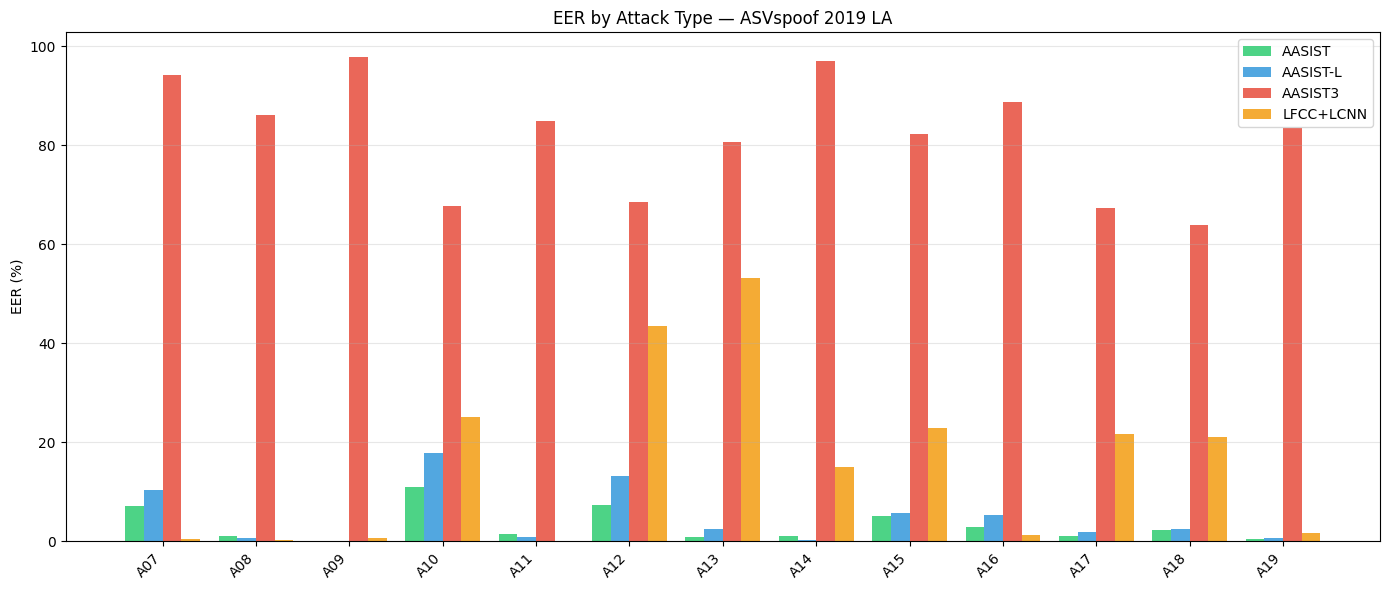

In [33]:
# ═══════════════════════════════════════════
# 6.3  EER by attack type — ASVspoof 2019 LA
# ═══════════════════════════════════════════
import matplotlib.pyplot as plt

def grouped_eer(df, group_col, score_cols):
    """Compute EER per group for multiple models. Only on spoof subsets (bonafide pooled)."""
    bonafide = df[df['label'] == 1]
    spoof_groups = df[df['label'] == 0].groupby(group_col)

    results = []
    for group_name, group_df in spoof_groups:
        # Pool bonafide with this spoof group
        subset = pd.concat([bonafide, group_df])
        row = {'group': group_name, 'n_spoof': len(group_df)}
        for col in score_cols:
            if col in subset.columns:
                row[col] = compute_eer(subset[col].values, subset['label'].values)
        results.append(row)
    return pd.DataFrame(results).sort_values('group')

# Models with scores in df_2019
score_cols_2019 = [c for c in df_2019.columns if c.startswith('score_')]
model_names_2019 = [c.replace('score_', '') for c in score_cols_2019]

eer_by_attack_2019 = grouped_eer(df_2019, 'attack', score_cols_2019)

print('EER (%) by Attack Type — ASVspoof 2019 LA')
print('=' * 70)
header = f'{"Attack":>10s} {"N_spoof":>8s}'
for m in model_names_2019:
    header += f' {m:>12s}'
print(header)
print('-' * 70)
for _, row in eer_by_attack_2019.iterrows():
    line = f'{row["group"]:>10s} {int(row["n_spoof"]):>8,}'
    for col in score_cols_2019:
        line += f' {row[col]:>11.2f}%'
    print(line)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(eer_by_attack_2019))
width = 0.8 / len(score_cols_2019)
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (col, name) in enumerate(zip(score_cols_2019, model_names_2019)):
    offset = (i - len(score_cols_2019)/2 + 0.5) * width
    ax.bar([xi + offset for xi in x], eer_by_attack_2019[col], width,
           label=name, color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(eer_by_attack_2019['group'], rotation=45, ha='right')
ax.set_ylabel('EER (%)')
ax.set_title('EER by Attack Type — ASVspoof 2019 LA')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

EER (%) by Codec — ASVspoof 2021 DF
       Codec  N_spoof       AASIST    LFCC+LCNN
------------------------------------------------------------
    high_m4a   49,061       48.49%       49.70%
    high_mp3   49,063       48.36%       48.59%
    high_ogg   49,060       48.39%       49.65%
     low_m4a   49,056       48.48%       50.03%
     low_mp3   49,072       48.41%       48.50%
     low_ogg   49,185       48.27%       50.04%
      mp3m4a   49,198       48.46%       48.45%
     nocodec   49,162       48.43%       49.88%
      oggm4a   49,034       48.51%       49.96%


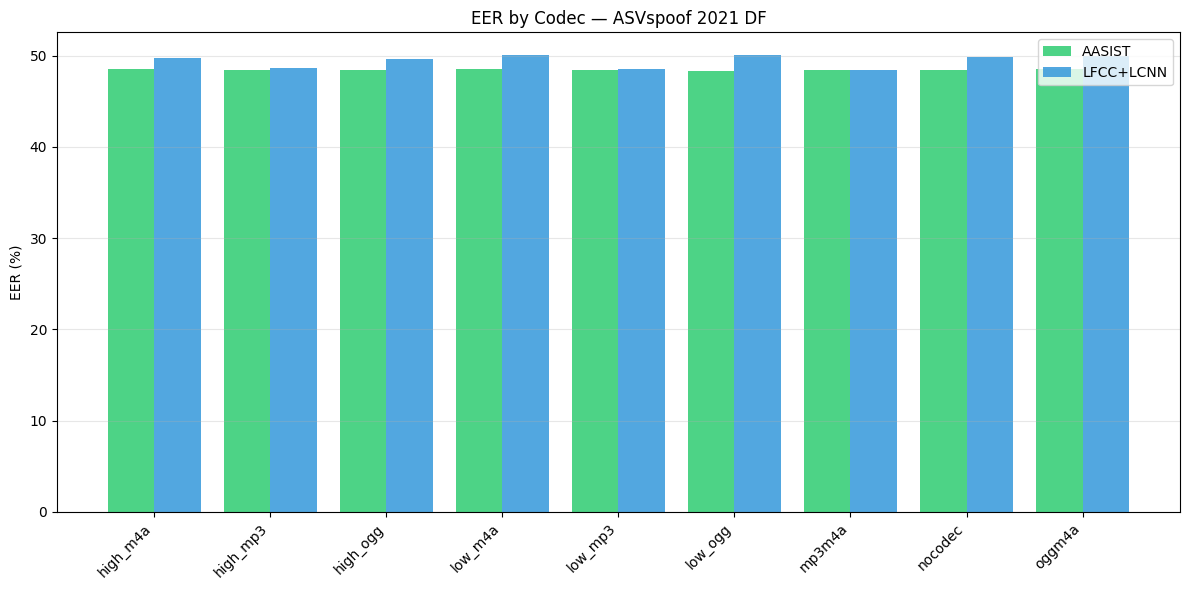

In [34]:
# ═══════════════════════════════════════════
# 6.4  EER by codec — ASVspoof 2021 DF
# ═══════════════════════════════════════════
score_cols_2021 = [c for c in df_2021.columns if c.startswith('score_')]
model_names_2021 = [c.replace('score_', '') for c in score_cols_2021]

eer_by_codec = grouped_eer(df_2021, 'codec', score_cols_2021)

print('EER (%) by Codec — ASVspoof 2021 DF')
print('=' * 60)
header = f'{"Codec":>12s} {"N_spoof":>8s}'
for m in model_names_2021:
    header += f' {m:>12s}'
print(header)
print('-' * 60)
for _, row in eer_by_codec.iterrows():
    line = f'{row["group"]:>12s} {int(row["n_spoof"]):>8,}'
    for col in score_cols_2021:
        line += f' {row[col]:>11.2f}%'
    print(line)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(eer_by_codec))
width = 0.8 / len(score_cols_2021)

for i, (col, name) in enumerate(zip(score_cols_2021, model_names_2021)):
    offset = (i - len(score_cols_2021)/2 + 0.5) * width
    ax.bar([xi + offset for xi in x], eer_by_codec[col], width,
           label=name, color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(eer_by_codec['group'], rotation=45, ha='right')
ax.set_ylabel('EER (%)')
ax.set_title('EER by Codec — ASVspoof 2021 DF')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

EER (%) by Vocoder Type — ASVspoof 2021 DF
                            Vocoder  N_spoof       AASIST    LFCC+LCNN
----------------------------------------------------------------------
      neural_vocoder_autoregressive  114,342       49.23%       49.70%
   neural_vocoder_nonautoregressive   90,519       48.85%       49.48%
                traditional_vocoder  206,913       47.80%       49.31%
                            unknown   21,645       48.09%       48.71%
             waveform_concatenation    8,472       48.48%       48.78%


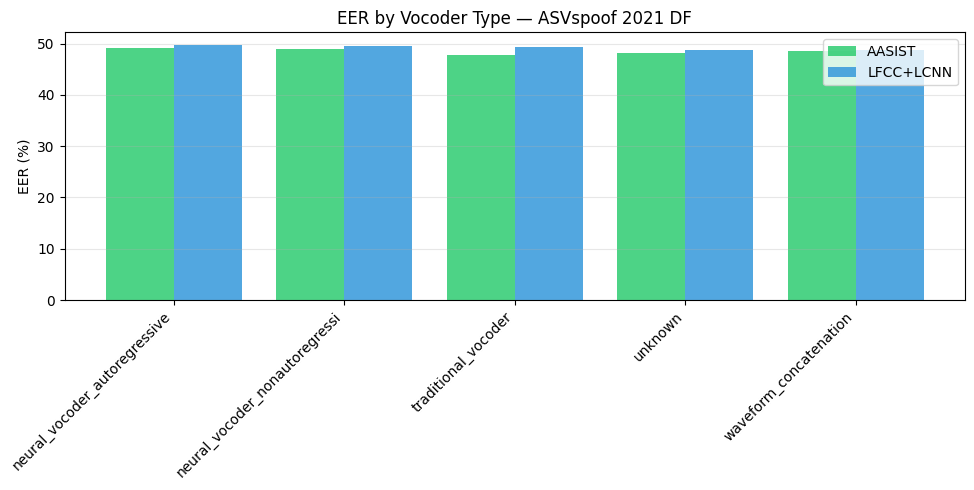

In [35]:
# ═══════════════════════════════════════════
# 6.5  EER by vocoder type — ASVspoof 2021 DF
# ═══════════════════════════════════════════
eer_by_vocoder = grouped_eer(df_2021, 'vocoder', score_cols_2021)

print('EER (%) by Vocoder Type — ASVspoof 2021 DF')
print('=' * 60)
header = f'{"Vocoder":>35s} {"N_spoof":>8s}'
for m in model_names_2021:
    header += f' {m:>12s}'
print(header)
print('-' * 70)
for _, row in eer_by_vocoder.iterrows():
    line = f'{row["group"]:>35s} {int(row["n_spoof"]):>8,}'
    for col in score_cols_2021:
        line += f' {row[col]:>11.2f}%'
    print(line)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(eer_by_vocoder))
width = 0.8 / len(score_cols_2021)

for i, (col, name) in enumerate(zip(score_cols_2021, model_names_2021)):
    offset = (i - len(score_cols_2021)/2 + 0.5) * width
    ax.bar([xi + offset for xi in x], eer_by_vocoder[col], width,
           label=name, color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels([v[:30] for v in eer_by_vocoder['group']], rotation=45, ha='right')
ax.set_ylabel('EER (%)')
ax.set_title('EER by Vocoder Type — ASVspoof 2021 DF')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

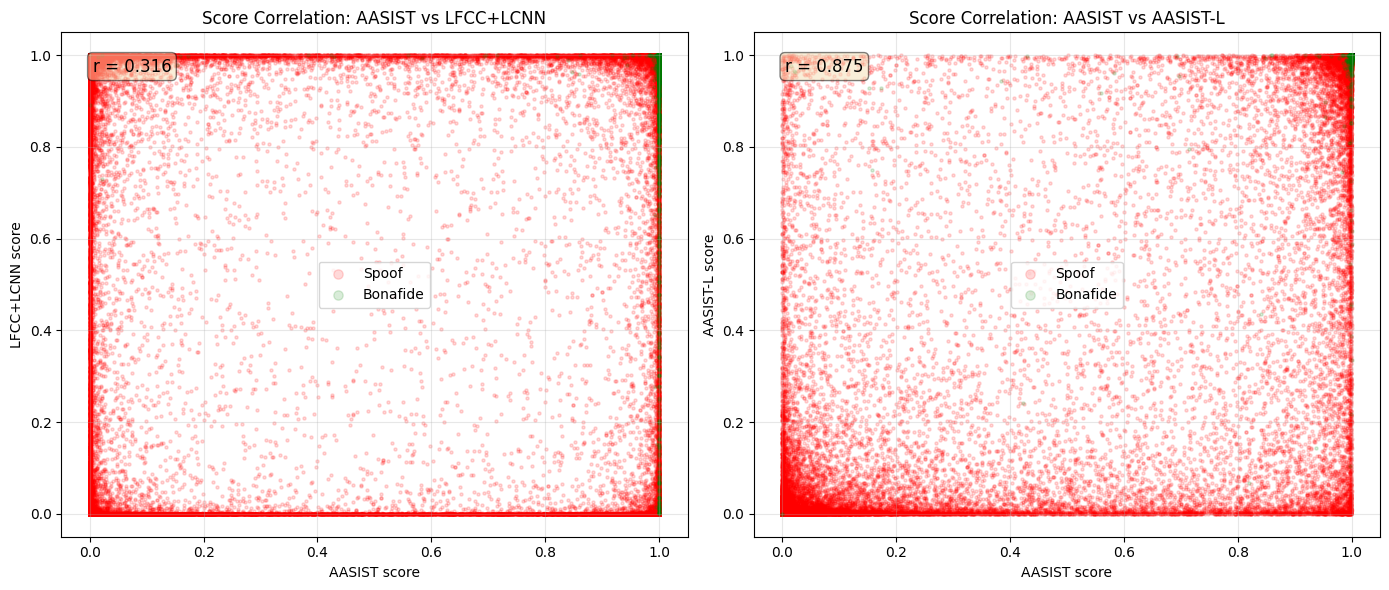


Failure Overlap Analysis (at EER threshold)

AASIST vs LFCC+LCNN:
  AASIST errors:    3,273
  LFCC+LCNN errors:    13,990
  Both wrong:     572
  Only AASIST:      2,701
  Only LFCC+LCNN:      13,418
  Overlap ratio:  4.1% (lower = more complementary)

AASIST vs AASIST-L:
  AASIST errors:    3,273
  AASIST-L errors:    4,805
  Both wrong:     2,317
  Only AASIST:      956
  Only AASIST-L:      2,488
  Overlap ratio:  48.2% (lower = more complementary)


In [36]:
# ═══════════════════════════════════════════
# 6.6  Cross-model complementarity — ASVspoof 2019 LA
# ═══════════════════════════════════════════
# Check if AASIST and LFCC+LCNN fail on different utterances → ensemble potential

score_pairs = []
for m1, m2 in [('AASIST', 'LFCC+LCNN'), ('AASIST', 'AASIST-L')]:
    c1, c2 = f'score_{m1}', f'score_{m2}'
    if c1 in df_2019.columns and c2 in df_2019.columns:
        score_pairs.append((m1, m2, c1, c2))

if score_pairs:
    fig, axes = plt.subplots(1, len(score_pairs), figsize=(7*len(score_pairs), 6))
    if len(score_pairs) == 1:
        axes = [axes]

    for ax, (m1, m2, c1, c2) in zip(axes, score_pairs):
        spoof = df_2019[df_2019['label'] == 0]
        bona = df_2019[df_2019['label'] == 1]
        ax.scatter(spoof[c1], spoof[c2], alpha=0.15, s=5, c='red', label='Spoof')
        ax.scatter(bona[c1], bona[c2], alpha=0.15, s=5, c='green', label='Bonafide')
        ax.set_xlabel(f'{m1} score')
        ax.set_ylabel(f'{m2} score')
        ax.set_title(f'Score Correlation: {m1} vs {m2}')
        ax.legend(markerscale=3)
        ax.grid(alpha=0.3)

        # Correlation coefficient
        corr = np.corrcoef(df_2019[c1], df_2019[c2])[0, 1]
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

# --- Failure overlap (using per-model EER threshold) ---
print('\nFailure Overlap Analysis (at EER threshold)')
print('=' * 60)
for m1, m2, c1, c2 in score_pairs:
    # Get EER thresholds
    for mname, col in [(m1, c1), (m2, c2)]:
        fpr, tpr, thresholds = roc_curve(df_2019['label'], df_2019[col], pos_label=1)
        fnr = 1 - tpr
        idx = np.nanargmin(np.abs(fpr - fnr))
        df_2019[f'pred_{mname}'] = (df_2019[col] >= thresholds[idx]).astype(int)

    # Count failures
    wrong_m1 = df_2019[df_2019[f'pred_{m1}'] != df_2019['label']]
    wrong_m2 = df_2019[df_2019[f'pred_{m2}'] != df_2019['label']]
    both_wrong = pd.merge(wrong_m1[['utt_id']], wrong_m2[['utt_id']], on='utt_id')

    n1, n2, nb = len(wrong_m1), len(wrong_m2), len(both_wrong)
    only_m1 = n1 - nb
    only_m2 = n2 - nb
    print(f'\n{m1} vs {m2}:')
    print(f'  {m1} errors:    {n1:,}')
    print(f'  {m2} errors:    {n2:,}')
    print(f'  Both wrong:     {nb:,}')
    print(f'  Only {m1}:      {only_m1:,}')
    print(f'  Only {m2}:      {only_m2:,}')
    print(f'  Overlap ratio:  {nb/max(n1,n2):.1%} (lower = more complementary)')

---
## Part 7: ASVspoof 5 Evaluation & Comparison to ASVspoof 2019/2021

Evaluate on ASVspoof 5 (2024) to test cross-dataset robustness under newer attacks, codec diversity, and more realistic conditions.

**Default split:** `dev` for manageable runtime on Kaggle. Change `ASV5_CONFIG['split']` to `'eval'` only if the full audio is mounted and long runtime is acceptable.  
**Goal:** compare each model not only by overall EER, but also by attack type, codec, and hardest-case groups across ASVspoof 2019, 2021, and 5.


In [ ]:
# ═══════════════════════════════════════════
# 7.0  Locate ASVspoof 5 and choose evaluation setup
# ═══════════════════════════════════════════
!pip install -q datasets soundfile

import os
import glob
from pathlib import Path

ASV5_CONFIG = {
    'split': 'dev',          # recommended first run on Kaggle
    'track': 'track_1',
    'max_items': None,       # set e.g. 50000 for a quick smoke test
    'streaming': False,      # use True only if HF download is too large
}

ASV5_RESULTS_DIR = f'{RESULTS_DIR}/asvspoof5'
os.makedirs(ASV5_RESULTS_DIR, exist_ok=True)

ASV5_PROTOCOL = None
ASV5_AUDIO_DIR = None
ASV5_SOURCE = None

protocol_patterns = [
    f"/kaggle/input/**/*{ASV5_CONFIG['split']}*{ASV5_CONFIG['track']}*.tsv",
    f"/kaggle/input/**/*{ASV5_CONFIG['track']}*{ASV5_CONFIG['split']}*.tsv",
    f"/kaggle/input/**/*{ASV5_CONFIG['split']}*.tsv",
]
audio_patterns = [
    f"/kaggle/input/**/*flac*{ASV5_CONFIG['split']}*",
    f"/kaggle/input/**/*{ASV5_CONFIG['split']}*flac*",
]

for pattern in protocol_patterns:
    candidates = sorted(glob.glob(pattern, recursive=True))
    if candidates:
        ASV5_PROTOCOL = candidates[0]
        break

for pattern in audio_patterns:
    candidates = [p for p in sorted(glob.glob(pattern, recursive=True)) if os.path.isdir(p)]
    if candidates:
        ASV5_AUDIO_DIR = candidates[0]
        break

if ASV5_PROTOCOL and ASV5_AUDIO_DIR:
    ASV5_SOURCE = 'local'
else:
    ASV5_SOURCE = 'huggingface'

print('ASVspoof 5 setup')
print('=' * 60)
print(f"  Split        : {ASV5_CONFIG['split']}")
print(f"  Track        : {ASV5_CONFIG['track']}")
print(f"  Source       : {ASV5_SOURCE}")
print(f"  Protocol     : {ASV5_PROTOCOL}")
print(f"  Audio dir    : {ASV5_AUDIO_DIR}")
print(f"  Max items    : {ASV5_CONFIG['max_items']}")
print(f"  Results dir  : {ASV5_RESULTS_DIR}")

if ASV5_CONFIG['split'] == 'eval':
    print('\n⚠️  eval split is large. Use dev first unless full run is intentional.')


In [ ]:
# ═══════════════════════════════════════════
# 7.1  Build ASVspoof 5 record list
# ═══════════════════════════════════════════
import pandas as pd
from itertools import islice
from datasets import load_dataset

def normalize_asv5_label(value):
    s = str(value).strip().lower()
    return 1 if 'bona' in s else 0

def normalize_asv5_group(value, default='unknown'):
    s = str(value).strip()
    return default if s in ('', '-', 'None', 'nan') else s

def find_first_key(sample, keys, fallback=None):
    for key in keys:
        if key in sample:
            return key
    return fallback

def load_asv5_local_records(protocol_path, audio_dir):
    df = pd.read_csv(protocol_path, sep='\t')
    if 'utt_id' not in df.columns or 'label' not in df.columns:
        df = pd.read_csv(protocol_path, sep='\t', header=None)
        rename_map = {
            0: 'speaker',
            1: 'utt_id',
            5: 'codec',
            6: 'attack',
            7: 'label',
        }
        df = df.rename(columns=rename_map)

    df['attack'] = df.get('attack', '-').map(lambda x: normalize_asv5_group(x, 'bonafide'))
    df['codec'] = df.get('codec', 'nocodec').map(lambda x: normalize_asv5_group(x, 'nocodec'))
    df['label'] = df['label'].map(normalize_asv5_label)

    audio_index = {}
    for path in Path(audio_dir).rglob('*.flac'):
        audio_index[path.stem] = str(path)

    df['audio_ref'] = df['utt_id'].map(audio_index)
    df = df[df['audio_ref'].notna()].reset_index(drop=True)

    if ASV5_CONFIG['max_items'] is not None:
        df = df.iloc[:ASV5_CONFIG['max_items']].copy()

    return [
        {
            'utt_id': row['utt_id'],
            'attack': row['attack'],
            'codec': row['codec'],
            'label': int(row['label']),
            'audio_ref': row['audio_ref'],
        }
        for _, row in df.iterrows()
    ]

def load_asv5_hf_records():
    split_candidates = [
        ASV5_CONFIG['split'],
        f"{ASV5_CONFIG['split']}.{ASV5_CONFIG['track']}",
        f"{ASV5_CONFIG['track']}_{ASV5_CONFIG['split']}",
    ]

    dataset = None
    last_error = None
    for split_name in split_candidates:
        try:
            dataset = load_dataset(
                'jungjee/asvspoof5',
                split=split_name,
                streaming=ASV5_CONFIG['streaming'],
            )
            print(f'Loaded HuggingFace split: {split_name}')
            break
        except Exception as exc:
            last_error = exc

    if dataset is None:
        raise RuntimeError(f'Cannot load ASVspoof 5 from HuggingFace: {last_error}')

    records = []
    iterator = dataset if ASV5_CONFIG['max_items'] is None else islice(dataset, ASV5_CONFIG['max_items'])

    for sample in iterator:
        utt_key = find_first_key(sample, ['utt_id', 'id', 'file', 'filename'], 'utt_id')
        attack_key = find_first_key(sample, ['attack', 'attack_id', 'spoofing_attack'], None)
        codec_key = find_first_key(sample, ['codec', 'codec_id', 'compression'], None)
        audio_key = find_first_key(sample, ['audio', 'path', 'speech'], None)
        label_key = find_first_key(sample, ['label', 'bonafide', 'class', 'target'], 'label')

        if audio_key is None:
            raise RuntimeError('Cannot infer ASVspoof 5 audio column from HuggingFace sample.')

        records.append(
            {
                'utt_id': str(sample.get(utt_key, f"sample_{len(records)}")),
                'attack': normalize_asv5_group(sample.get(attack_key, 'unknown'), 'unknown'),
                'codec': normalize_asv5_group(sample.get(codec_key, 'nocodec'), 'nocodec'),
                'label': normalize_asv5_label(sample.get(label_key, 0)),
                'audio_ref': sample[audio_key],
            }
        )

    return records

if ASV5_SOURCE == 'local':
    ASV5_RECORDS = load_asv5_local_records(ASV5_PROTOCOL, ASV5_AUDIO_DIR)
else:
    ASV5_RECORDS = load_asv5_hf_records()

print(f'ASVspoof 5 records ready: {len(ASV5_RECORDS):,}')
if ASV5_RECORDS:
    preview = pd.DataFrame(ASV5_RECORDS[:5]).drop(columns=['audio_ref'], errors='ignore')
    display(preview)

    attack_counts = pd.Series([r['attack'] for r in ASV5_RECORDS]).value_counts().head(10)
    codec_counts = pd.Series([r['codec'] for r in ASV5_RECORDS]).value_counts()
    print('\nTop attack groups:')
    print(attack_counts.to_string())
    print('\nCodec distribution:')
    print(codec_counts.to_string())


In [ ]:
# ═══════════════════════════════════════════
# 7.2  Evaluate models on ASVspoof 5
# ═══════════════════════════════════════════
import sys
import json
import importlib

def load_audio_16k(audio_ref):
    if isinstance(audio_ref, str):
        wav, sr = torchaudio.load(audio_ref)
    elif isinstance(audio_ref, dict):
        if 'array' not in audio_ref or 'sampling_rate' not in audio_ref:
            raise ValueError('Unsupported audio dict format.')
        wav = torch.from_numpy(audio_ref['array']).float().unsqueeze(0)
        sr = audio_ref['sampling_rate']
    else:
        raise TypeError(f'Unsupported audio reference type: {type(audio_ref)}')

    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != 16000:
        wav = torchaudio.transforms.Resample(sr, 16000)(wav)
    return wav

def predict_aasist_wav(model, wav, device='cuda', cut=64600):
    if wav.shape[1] < cut:
        wav = torch.nn.functional.pad(wav, (0, cut - wav.shape[1]))
    else:
        wav = wav[:, :cut]
    with torch.no_grad():
        _, out = model(wav.to(device))
    scores = out.softmax(dim=1).cpu().numpy()[0]
    return float(scores[1])  # bonafide score

def predict_aasist3_wav(model, wav, device='cuda', cut=64600):
    if wav.shape[1] < cut:
        wav = torch.nn.functional.pad(wav, (0, cut - wav.shape[1]))
    else:
        wav = wav[:, :cut]
    with torch.no_grad():
        out = model(wav.to(device))
    probs = torch.softmax(out, dim=1).cpu().numpy()[0]
    return float(probs[0])  # class 0 = bonafide for this checkpoint

def predict_lcnn_wav(model, wav, device='cuda', max_frames=400):
    feat = lfcc_transform(wav)
    T = feat.shape[2]
    if T < max_frames:
        feat = torch.nn.functional.pad(feat, (0, max_frames - T))
    else:
        feat = feat[:, :, :max_frames]
    with torch.no_grad():
        logits = model(feat.unsqueeze(0).to(device))
        score = torch.softmax(logits, dim=1)[0, 1].item()
    return score

def evaluate_asv5_model(model_name, model, predict_fn):
    scores, labels, meta = [], [], []
    errors = 0
    t0 = time.time()

    for record in tqdm(ASV5_RECORDS, desc=f'{model_name} → ASVspoof5'):
        try:
            wav = load_audio_16k(record['audio_ref'])
            score = predict_fn(model, wav, device)
            scores.append(score)
            labels.append(record['label'])
            meta.append({
                'utt_id': record['utt_id'],
                'attack': record['attack'],
                'codec': record['codec'],
            })
        except Exception as exc:
            errors += 1
            if errors <= 3:
                print(f'  Error on {record.get("utt_id", "?")}: {type(exc).__name__}: {exc}')

    scores_arr = np.array(scores)
    labels_arr = np.array(labels)
    eer = compute_eer(scores_arr, labels_arr) if len(scores_arr) else float('nan')

    return {
        'eer': eer,
        'scores': scores_arr,
        'labels': labels_arr,
        'meta': meta,
        'n_errors': errors,
        'elapsed_sec': time.time() - t0,
        'split': ASV5_CONFIG['split'],
    }

RESULTS_ASV5 = {}

if not Path('/kaggle/working/aasist').exists():
    !git clone https://github.com/clovaai/aasist.git /kaggle/working/aasist

sys.path.insert(0, '/kaggle/working/aasist')
os.chdir('/kaggle/working/aasist')

with open('config/AASIST.conf') as f:
    cfg = json.load(f)
mod = importlib.import_module(f'models.{cfg["model_config"]["architecture"]}')
aasist_model = mod.Model(cfg['model_config']).to(device)
aasist_model.load_state_dict(torch.load('models/weights/AASIST.pth', map_location=device))
aasist_model.eval()
RESULTS_ASV5['AASIST'] = evaluate_asv5_model('AASIST', aasist_model, predict_aasist_wav)
print(f"🎯 AASIST on ASVspoof5 {ASV5_CONFIG['split']}: EER = {RESULTS_ASV5['AASIST']['eer']:.2f}%")
del aasist_model
torch.cuda.empty_cache()

with open('config/AASIST-L.conf') as f:
    cfg_l = json.load(f)
mod_l = importlib.import_module(f'models.{cfg_l["model_config"]["architecture"]}')
aasist_l_model = mod_l.Model(cfg_l['model_config']).to(device)
aasist_l_model.load_state_dict(torch.load('models/weights/AASIST-L.pth', map_location=device))
aasist_l_model.eval()
RESULTS_ASV5['AASIST-L'] = evaluate_asv5_model('AASIST-L', aasist_l_model, predict_aasist_wav)
print(f"🎯 AASIST-L on ASVspoof5 {ASV5_CONFIG['split']}: EER = {RESULTS_ASV5['AASIST-L']['eer']:.2f}%")
del aasist_l_model
torch.cuda.empty_cache()

if Path('/kaggle/working/lfcc_lcnn.pth').exists():
    lcnn = SimpleLCNN().to(device)
    lcnn.load_state_dict(torch.load('/kaggle/working/lfcc_lcnn.pth', map_location=device))
    lcnn.eval()
    RESULTS_ASV5['LFCC+LCNN'] = evaluate_asv5_model('LFCC+LCNN', lcnn, predict_lcnn_wav)
    print(f"🎯 LFCC+LCNN on ASVspoof5 {ASV5_CONFIG['split']}: EER = {RESULTS_ASV5['LFCC+LCNN']['eer']:.2f}%")
    del lcnn
    torch.cuda.empty_cache()
else:
    print('⚠️  /kaggle/working/lfcc_lcnn.pth not found → skip LFCC+LCNN.')

try:
    if not Path('/kaggle/working/AASIST3').exists():
        !git clone https://github.com/mtuciru/AASIST3.git /kaggle/working/AASIST3
        !pip install -q transformers huggingface_hub

    sys.path.insert(0, '/kaggle/working/AASIST3')
    os.chdir('/kaggle/working/AASIST3')
    from model import aasist3

    aasist3_model = aasist3.from_pretrained('MTUCI/AASIST3').eval().to(device)
    RESULTS_ASV5['AASIST3'] = evaluate_asv5_model('AASIST3', aasist3_model, predict_aasist3_wav)
    print(f"🎯 AASIST3 on ASVspoof5 {ASV5_CONFIG['split']}: EER = {RESULTS_ASV5['AASIST3']['eer']:.2f}%")
    del aasist3_model
    torch.cuda.empty_cache()
except Exception as exc:
    print(f'⚠️  AASIST3 skipped: {type(exc).__name__}: {exc}')

os.chdir('/kaggle/working')

print('\nSummary:')
for name, data in sorted(RESULTS_ASV5.items(), key=lambda x: x[1]['eer']):
    print(f"  {name:15s}  EER = {data['eer']:.2f}%  (N={len(data['scores']):,}, errors={data['n_errors']})")


In [ ]:
# ═══════════════════════════════════════════
# 7.3  ASVspoof 5 grouped EER by attack and codec
# ═══════════════════════════════════════════
import matplotlib.pyplot as plt

def grouped_eer_from_result(result, group_col):
    df = pd.DataFrame(result['meta']).copy()
    df['score'] = result['scores']
    df['label'] = result['labels']

    bonafide = df[df['label'] == 1]
    rows = []
    for group_name, group_df in df[df['label'] == 0].groupby(group_col):
        subset = pd.concat([bonafide, group_df], ignore_index=True)
        rows.append({
            group_col: group_name,
            'n_spoof': len(group_df),
            'eer': compute_eer(subset['score'].values, subset['label'].values),
        })
    return pd.DataFrame(rows).sort_values(group_col)

ASV5_GROUP_TABLES = {}

for group_col, title in [('attack', 'Attack'), ('codec', 'Codec')]:
    merged = None
    for model_name, result in RESULTS_ASV5.items():
        table = grouped_eer_from_result(result, group_col)
        table = table.rename(columns={'eer': model_name})
        merged = table if merged is None else merged.merge(table, on=[group_col, 'n_spoof'], how='outer')

    if merged is None or merged.empty:
        continue

    ASV5_GROUP_TABLES[group_col] = merged
    display(merged)
    merged.to_csv(f'{ASV5_RESULTS_DIR}/eer_by_{group_col}_{ASV5_CONFIG["split"]}.csv', index=False)

    model_cols = [c for c in merged.columns if c not in (group_col, 'n_spoof')]
    fig, ax = plt.subplots(figsize=(14, 6))
    x = range(len(merged))
    width = 0.8 / max(1, len(model_cols))
    colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

    for i, col in enumerate(model_cols):
        offset = (i - len(model_cols) / 2 + 0.5) * width
        ax.bar([xi + offset for xi in x], merged[col], width, label=col, color=colors[i % len(colors)], alpha=0.85)

    ax.set_xticks(list(x))
    ax.set_xticklabels(merged[group_col], rotation=45, ha='right')
    ax.set_ylabel('EER (%)')
    ax.set_title(f'ASVspoof 5 {ASV5_CONFIG["split"]}: EER by {title}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{ASV5_RESULTS_DIR}/eer_by_{group_col}_{ASV5_CONFIG["split"]}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# ═══════════════════════════════════════════
# 7.4  Cross-dataset comparison: ASVspoof 2019 vs 2021 vs 5
# ═══════════════════════════════════════════
rows = []
all_models = sorted(set(ALL_RESULTS) | set(RESULTS_2021) | set(RESULTS_ASV5))

for model_name in all_models:
    e19 = ALL_RESULTS.get(model_name, {}).get('eer', float('nan'))
    e21 = RESULTS_2021.get(model_name, {}).get('eer', float('nan'))
    e5 = RESULTS_ASV5.get(model_name, {}).get('eer', float('nan'))
    rows.append({
        'model': model_name,
        'asv19_la_eer': e19,
        'asv21_df_eer': e21,
        f'asv5_{ASV5_CONFIG["split"]}_eer': e5,
        'delta_21_minus_19': e21 - e19 if pd.notna(e19) and pd.notna(e21) else float('nan'),
        'delta_5_minus_19': e5 - e19 if pd.notna(e19) and pd.notna(e5) else float('nan'),
    })

cross_dataset_df = pd.DataFrame(rows).sort_values('model')
display(cross_dataset_df)
cross_dataset_df.to_csv(f'{ASV5_RESULTS_DIR}/cross_dataset_summary_{ASV5_CONFIG["split"]}.csv', index=False)

def hardest_group(table, model_name):
    if table is None or model_name not in table.columns or table.empty:
        return float('nan')
    return float(table[model_name].max())

attack_table_2019 = globals().get('eer_by_attack_2019')
codec_table_2021 = globals().get('eer_by_codec')
vocoder_table_2021 = globals().get('eer_by_vocoder')
attack_table_5 = ASV5_GROUP_TABLES.get('attack')
codec_table_5 = ASV5_GROUP_TABLES.get('codec')

profile_rows = []
for model_name in all_models:
    score_2019 = f'score_{model_name}'
    score_2021 = f'score_{model_name}'
    profile_rows.append({
        'model': model_name,
        'asv19_overall': ALL_RESULTS.get(model_name, {}).get('eer', float('nan')),
        'asv19_hardest_attack': hardest_group(attack_table_2019, score_2019) if attack_table_2019 is not None else float('nan'),
        'asv21_overall': RESULTS_2021.get(model_name, {}).get('eer', float('nan')),
        'asv21_hardest_codec': hardest_group(codec_table_2021, score_2021) if codec_table_2021 is not None else float('nan'),
        'asv21_hardest_vocoder': hardest_group(vocoder_table_2021, score_2021) if vocoder_table_2021 is not None else float('nan'),
        f'asv5_{ASV5_CONFIG["split"]}_overall': RESULTS_ASV5.get(model_name, {}).get('eer', float('nan')),
        f'asv5_{ASV5_CONFIG["split"]}_hardest_attack': hardest_group(attack_table_5, model_name),
        f'asv5_{ASV5_CONFIG["split"]}_hardest_codec': hardest_group(codec_table_5, model_name),
    })

difficulty_profile_df = pd.DataFrame(profile_rows).sort_values('model')
display(difficulty_profile_df)
difficulty_profile_df.to_csv(f'{ASV5_RESULTS_DIR}/difficulty_profile_{ASV5_CONFIG["split"]}.csv', index=False)

for name, data in RESULTS_ASV5.items():
    safe = name.replace('+', '_').replace(' ', '_')
    meta_df = pd.DataFrame(data['meta'])
    np.savez(
        f'{ASV5_RESULTS_DIR}/scores_asvspoof5_{ASV5_CONFIG["split"]}_{safe}.npz',
        scores=data['scores'],
        labels=data['labels'],
        utt_ids=meta_df.get('utt_id', pd.Series(dtype=str)).astype(str).values,
        attacks=meta_df.get('attack', pd.Series(dtype=str)).astype(str).values,
        codecs=meta_df.get('codec', pd.Series(dtype=str)).astype(str).values,
        eer=data['eer'],
    )

print(f'💾 ASVspoof 5 artifacts saved to {ASV5_RESULTS_DIR}/')


---
## Part 8: EchoFake Evaluation (2025)

Evaluate on [EchoFake](https://huggingface.co/datasets/EchoFake/EchoFake) — first dataset with **physical replay attacks**.

**4 labels:** bonafide (B), replayed bonafide (RB), fake (F), replayed fake (RF)  
**Binary mapping:** B → bonafide (1), RB+F+RF → spoof (0)  
**Splits:** `closed_set_eval` (6K, known attacks) · `open_set_eval` (25.6K, unseen TTS + replay conditions)

In [ ]:
# ═══════════════════════════════════════════
# 8.0  Load EchoFake dataset
# ═══════════════════════════════════════════
!pip install -q datasets soundfile

from datasets import load_dataset

ds = load_dataset("EchoFake/EchoFake", trust_remote_code=True)
print(f'Splits: {list(ds.keys())}')
for split in ds:
    print(f'  {split}: {len(ds[split]):,} samples')

# Preview label distribution in eval splits
for split in ['closed_set_eval', 'open_set_eval']:
    from collections import Counter
    labels = Counter(ds[split]['label'])
    print(f'\n{split} label distribution:')
    for label, count in sorted(labels.items()):
        print(f'  {label:25s}: {count:,}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'EchoFake/EchoFake' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/462M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/438M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/415M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/39926 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/3973 [00:00<?, ? examples/s]

Generating closed_set_eval split:   0%|          | 0/5991 [00:00<?, ? examples/s]

Generating open_set_eval split:   0%|          | 0/25600 [00:00<?, ? examples/s]

Splits: ['train', 'dev', 'closed_set_eval', 'open_set_eval']
  train: 39,926 samples
  dev: 3,973 samples
  closed_set_eval: 5,991 samples
  open_set_eval: 25,600 samples

closed_set_eval label distribution:
  bonafide                 : 1,500
  fake                     : 1,500
  replay_bonafide          : 1,498
  replay_fake              : 1,493

open_set_eval label distribution:
  bonafide                 : 6,400
  fake                     : 6,400
  replay_bonafide          : 6,400
  replay_fake              : 6,400


In [ ]:
# ═══════════════════════════════════════════
# 8.1  Prepare EchoFake for inference
# ═══════════════════════════════════════════
# HF audio column returns {'array': np.ndarray, 'sampling_rate': int}
# Need helper to convert to tensor for our models

LABEL_MAP = {'bonafide': 1}  # everything else → 0

def echofake_to_wav_tensor(sample):
    """Convert HF audio sample to (1, T) torch tensor at 16kHz."""
    audio = sample['path']  # {'array': np.ndarray, 'sampling_rate': int}
    wav = torch.from_numpy(audio['array']).float().unsqueeze(0)  # (1, T)
    sr = audio['sampling_rate']
    if sr != 16000:
        wav = torchaudio.transforms.Resample(sr, 16000)(wav)
    return wav

def predict_aasist_wav(model, wav, device='cuda', cut=64600):
    """Run AASIST on a (1, T) tensor directly (no file I/O)."""
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if wav.shape[1] < cut:
        wav = torch.nn.functional.pad(wav, (0, cut - wav.shape[1]))
    else:
        wav = wav[:, :cut]
    wav = wav.to(device)
    with torch.no_grad():
        _, out = model(wav)
    scores = out.softmax(dim=1).cpu().numpy()[0]
    return float(scores[1])  # bonafide score

def predict_lcnn_wav(model, wav, device='cuda', max_frames=400):
    """Run LFCC+LCNN on a (1, T) tensor directly."""
    feat = lfcc_transform(wav)  # (1, 60, T)
    T = feat.shape[2]
    if T < max_frames:
        feat = torch.nn.functional.pad(feat, (0, max_frames - T))
    else:
        feat = feat[:, :, :max_frames]
    with torch.no_grad():
        logits = model(feat.unsqueeze(0).to(device))
        s = torch.softmax(logits, dim=1)[0, 1].item()
    return s

# Quick sanity check on 1 sample
sample = ds['closed_set_eval'][0]
wav = echofake_to_wav_tensor(sample)
label = LABEL_MAP.get(sample['label'], 0)
print(f'Sample: label={sample["label"]} → binary={label}, wav shape={wav.shape}, sr=16kHz')
print('✅ Helpers ready!')

Sample: label=bonafide → binary=1, wav shape=torch.Size([1, 89856]), sr=16kHz
✅ Helpers ready!


In [ ]:
# ═══════════════════════════════════════════
# 8.2  Evaluate AASIST on EchoFake
# ═══════════════════════════════════════════
import sys, json, importlib

# Reload AASIST
sys.path.insert(0, '/kaggle/working/aasist')
os.chdir('/kaggle/working/aasist')
with open('config/AASIST.conf') as f:
    cfg = json.load(f)
mod = importlib.import_module(f'models.{cfg["model_config"]["architecture"]}')
aasist_model = mod.Model(cfg['model_config']).to(device)
aasist_model.load_state_dict(torch.load('models/weights/AASIST.pth', map_location=device))
aasist_model.eval()
print('✅ AASIST reloaded')

RESULTS_ECHOFAKE = {}

for split_name in ['closed_set_eval', 'open_set_eval']:
    split = ds[split_name]
    scores, labels, categories = [], [], []
    errors = 0
    t0 = time.time()

    for i in tqdm(range(len(split)), desc=f'AASIST → {split_name}'):
        try:
            sample = split[i]
            wav = echofake_to_wav_tensor(sample)
            s = predict_aasist_wav(aasist_model, wav, device)
            scores.append(s)
            labels.append(LABEL_MAP.get(sample['label'], 0))
            categories.append(sample['label'])
        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f'  Error [{i}]: {e}')

    elapsed = time.time() - t0
    scores_arr, labels_arr = np.array(scores), np.array(labels)
    eer = compute_eer(scores_arr, labels_arr)

    key = f'AASIST_{split_name}'
    RESULTS_ECHOFAKE[key] = {
        'eer': eer, 'scores': scores_arr, 'labels': labels_arr,
        'categories': categories,
    }
    print(f'🎯 AASIST on {split_name}: EER = {eer:.2f}%  ({elapsed:.0f}s, errors={errors})')

del aasist_model
torch.cuda.empty_cache()

✅ AASIST reloaded


AASIST → closed_set_eval: 100%|██████████| 5991/5991 [1:23:00<00:00,  1.20it/s]


🎯 AASIST on closed_set_eval: EER = 45.95%  (4981s, errors=0)


AASIST → open_set_eval: 100%|██████████| 25600/25600 [5:54:45<00:00,  1.20it/s]

🎯 AASIST on open_set_eval: EER = 46.04%  (21286s, errors=0)


In [ ]:
# ═══════════════════════════════════════════
# 8.3  Evaluate LFCC+LCNN on EchoFake
# ═══════════════════════════════════════════

lcnn = SimpleLCNN().to(device)
lcnn.load_state_dict(torch.load('/kaggle/working/lfcc_lcnn.pth', map_location=device))
lcnn.eval()
print('✅ LFCC+LCNN reloaded')

for split_name in ['closed_set_eval', 'open_set_eval']:
    split = ds[split_name]
    scores, labels, categories = [], [], []
    errors = 0
    t0 = time.time()

    for i in tqdm(range(len(split)), desc=f'LFCC+LCNN → {split_name}'):
        try:
            sample = split[i]
            wav = echofake_to_wav_tensor(sample)
            s = predict_lcnn_wav(lcnn, wav, device)
            scores.append(s)
            labels.append(LABEL_MAP.get(sample['label'], 0))
            categories.append(sample['label'])
        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f'  Error [{i}]: {e}')

    elapsed = time.time() - t0
    scores_arr, labels_arr = np.array(scores), np.array(labels)
    eer = compute_eer(scores_arr, labels_arr)

    key = f'LFCC+LCNN_{split_name}'
    RESULTS_ECHOFAKE[key] = {
        'eer': eer, 'scores': scores_arr, 'labels': labels_arr,
        'categories': categories,
    }
    print(f'🎯 LFCC+LCNN on {split_name}: EER = {eer:.2f}%  ({elapsed:.0f}s, errors={errors})')

del lcnn
torch.cuda.empty_cache()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/lfcc_lcnn.pth'

In [ ]:
# ═══════════════════════════════════════════
# 8.4  Per-category EER breakdown + Summary
# ═══════════════════════════════════════════
import matplotlib.pyplot as plt

# --- Per-category EER: B vs each spoof type ---
print('=' * 70)
print('  📊  EchoFake — Per-Category EER (bonafide vs each spoof type)')
print('=' * 70)

cat_labels = {'bonafide': 'B', 'replay': 'RB', 'fake': 'F', 'replayed_fake': 'RF'}

for split_name in ['closed_set_eval', 'open_set_eval']:
    print(f'\n--- {split_name} ---')
    print(f'{"Model":15s} | {"Overall":>8s} | {"B vs RB":>8s} | {"B vs F":>8s} | {"B vs RF":>8s}')
    print('-' * 60)

    for model_name in ['AASIST', 'LFCC+LCNN']:
        key = f'{model_name}_{split_name}'
        if key not in RESULTS_ECHOFAKE:
            continue
        res = RESULTS_ECHOFAKE[key]
        cats = np.array(res['categories'])
        scores = res['scores']
        labels = res['labels']

        # Overall EER
        overall = res['eer']

        # Per-category: bonafide scores vs each spoof category
        bona_mask = cats == 'bonafide'
        bona_scores = scores[bona_mask]
        bona_labels = labels[bona_mask]

        per_cat = {}
        for spoof_cat in ['replay', 'fake', 'replayed_fake']:
            spoof_mask = cats == spoof_cat
            if spoof_mask.sum() == 0:
                per_cat[spoof_cat] = float('nan')
                continue
            cat_scores = np.concatenate([bona_scores, scores[spoof_mask]])
            cat_labels = np.concatenate([bona_labels, labels[spoof_mask]])
            per_cat[spoof_cat] = compute_eer(cat_scores, cat_labels)

        print(f'{model_name:15s} | {overall:>7.2f}% | {per_cat.get("replay", float("nan")):>7.2f}% | '
              f'{per_cat.get("fake", float("nan")):>7.2f}% | {per_cat.get("replayed_fake", float("nan")):>7.2f}%')

# --- Summary table: all datasets ---
print('\n\n' + '=' * 70)
print('  📊  CROSS-DATASET SUMMARY')
print('=' * 70)
print(f'{"Model":15s} | {"ASV19 LA":>9s} | {"ASV21 DF":>9s} | {"EF closed":>10s} | {"EF open":>10s}')
print('-' * 70)

for model_name in ['AASIST', 'LFCC+LCNN']:
    e19 = ALL_RESULTS.get(model_name, {}).get('eer', float('nan'))
    e21 = RESULTS_2021.get(model_name, {}).get('eer', float('nan'))
    ec = RESULTS_ECHOFAKE.get(f'{model_name}_closed_set_eval', {}).get('eer', float('nan'))
    eo = RESULTS_ECHOFAKE.get(f'{model_name}_open_set_eval', {}).get('eer', float('nan'))
    print(f'{model_name:15s} | {e19:>8.2f}% | {e21:>8.2f}% | {ec:>9.2f}% | {eo:>9.2f}%')

print('=' * 70)

# --- Save ---
for key, data in RESULTS_ECHOFAKE.items():
    safe = key.replace('+', '_').replace(' ', '_')
    np.savez(f'{RESULTS_DIR}/scores_echofake_{safe}.npz',
             scores=data['scores'], labels=data['labels'],
             categories=data['categories'], eer=data['eer'])
print(f'\n💾 EchoFake results saved to {RESULTS_DIR}/')